# Experiment 11: Feature Importance

This experiment examines which variables contribute most to model predictions and validates whether the engineered features provide meaningful predictive value.

,Feature,Importance
5,temperature_difference,0.203413
7,mechanical_stress_index,0.190804
6,power_proxy,0.180433
2,rotational_speed_rpm,0.101906
4,tool_wear_min,0.095960
3,torque_nm,0.093837
10,Type_L,0.043670
0,air_temperature_k,0.024629
11,Type_M,0.023015
8,thermal_stress_index,0.014372


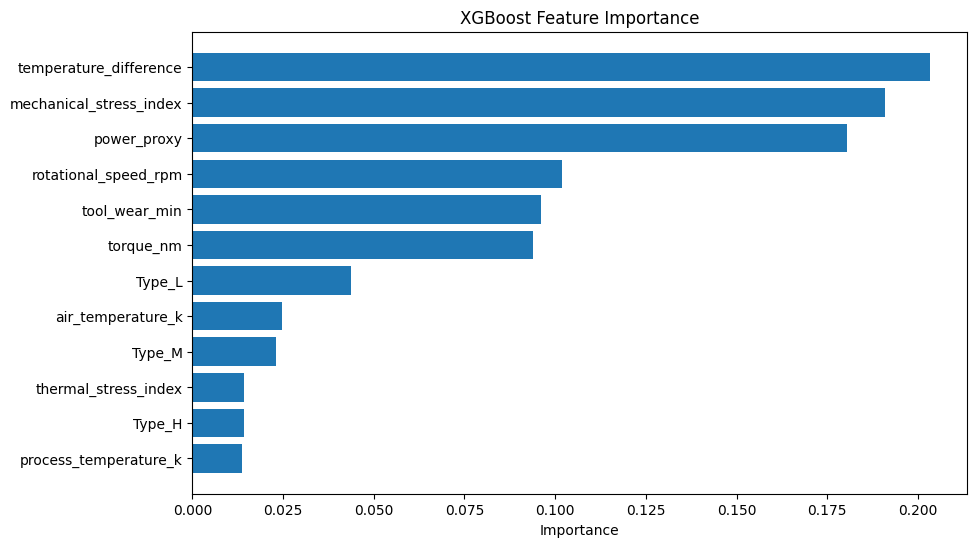

In [1]:
# ===================================================
# Imports
# ===================================================

from pathlib import Path
import sys

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.data.load_data import load_ai4i_dataset

from src.features.feature_engineering import (
    create_engineered_features
)

from src.features.preprocessing import (
    prepare_modeling_dataset
)

from src.models.train_xgboost import (
    build_xgboost_model
)

from src.explainability.feature_importance import (
    get_feature_importance
)

from sklearn.model_selection import (
    train_test_split
)

import matplotlib.pyplot as plt


# ===================================================
# Pipeline
# ===================================================

df = load_ai4i_dataset()

df = create_engineered_features(df)

df = prepare_modeling_dataset(df)

X = df.drop(
    columns=["Machine failure"]
)

y = df["Machine failure"]


X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)


# ===================================================
# Train Champion Model
# ===================================================

model = build_xgboost_model()

model.fit(
    X_train,
    y_train
)


# ===================================================
# Feature Importance
# ===================================================

importance_df = get_feature_importance(

    model,

    X.columns

)

display(
    importance_df
)


# ===================================================
# Plot
# ===================================================

plt.figure(
    figsize=(10,6)
)

plt.barh(

    importance_df["Feature"],

    importance_df["Importance"]

)

plt.gca().invert_yaxis()

plt.title(
    "XGBoost Feature Importance"
)

plt.xlabel(
    "Importance"
)

plt.show()

## Experiment 11 Findings

The feature importance analysis showed that the most influential predictors were engineered features rather than the original sensor measurements.

Temperature Difference, Mechanical Stress Index, and Power Proxy emerged as the three most important features in the final model, indicating that domain inspired feature engineering significantly improved predictive capability.

Among the original variables, rotational speed, tool wear, and torque remained important contributors to machine failure prediction.
